In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [4]:
model = load_model("best_heritage_model.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [5]:
train_directory = "train"

class_names = sorted(
    [
        folder_name
        for folder_name in os.listdir(train_directory)
        if os.path.isdir(
            os.path.join(train_directory, folder_name)
        )
    ]
)

print("Number of classes:", len(class_names))
print("Class names:")

for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

Number of classes: 10
Class names:
0 -> altar
1 -> apse
2 -> bell_tower
3 -> column
4 -> dome(inner)
5 -> dome(outer)
6 -> flying_buttress
7 -> gargoyle
8 -> stained_glass
9 -> vault


In [6]:
print(
    "Model output classes:",
    model.output_shape[-1]
)

print(
    "Class-name count:",
    len(class_names)
)

Model output classes: 10
Class-name count: 10


In [7]:
print("Model input shape:", model.input_shape)

IMAGE_HEIGHT = model.input_shape[1]
IMAGE_WIDTH = model.input_shape[2]

print("Image height:", IMAGE_HEIGHT)
print("Image width:", IMAGE_WIDTH)

Model input shape: (None, 224, 224, 3)
Image height: 224
Image width: 224


In [8]:
import random

test_class = random.choice(class_names)

test_class_folder = os.path.join(
    "test",
    test_class
)

image_files = [
    file_name
    for file_name in os.listdir(test_class_folder)
    if file_name.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

selected_file = random.choice(image_files)

image_path = os.path.join(
    test_class_folder,
    selected_file
)

print("True class:", test_class)
print("Selected image:", image_path)

True class: bell_tower
Selected image: test\bell_tower\1361.jpg


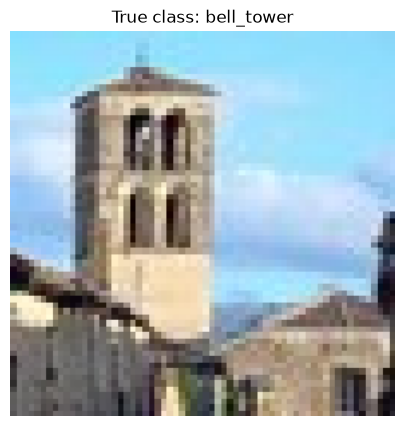

In [9]:
uploaded_image = image.load_img(
    image_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH)
)

plt.figure(figsize=(5, 5))
plt.imshow(uploaded_image)
plt.title("True class: " + test_class)
plt.axis("off")
plt.show()

In [10]:
image_array = image.img_to_array(
    uploaded_image
)

image_batch = np.expand_dims(
    image_array,
    axis=0
)

print("Single image shape:", image_array.shape)
print("Batch shape:", image_batch.shape)

Single image shape: (224, 224, 3)
Batch shape: (1, 224, 224, 3)


In [11]:
prediction_scores = model.predict(
    image_batch
)

predicted_index = np.argmax(
    prediction_scores[0]
)

predicted_class = class_names[
    predicted_index
]

confidence = np.max(
    prediction_scores[0]
) * 100

print("True class:", test_class)
print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 [==============================] - 4s 4s/step
True class: bell_tower
Predicted class: bell_tower
Confidence: 99.91 %


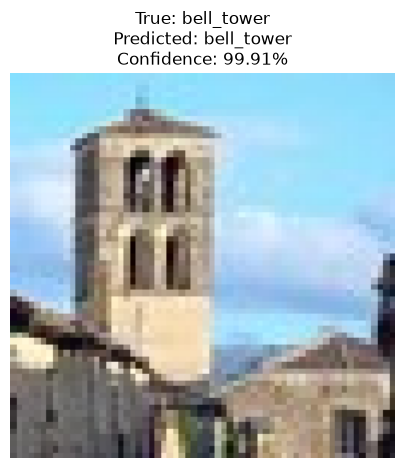

In [12]:
plt.figure(figsize=(5, 5))
plt.imshow(uploaded_image)

plt.title(
    "True: " + test_class +
    "\nPredicted: " + predicted_class +
    "\nConfidence: " +
    str(round(confidence, 2)) + "%"
)

plt.axis("off")
plt.show()

In [13]:
prediction_result = {
    "predicted_class": predicted_class,
    "confidence_percent": round(
        float(confidence),
        2
    ),
    "predicted_index": int(
        predicted_index
    ),
    "image_path": image_path
}

prediction_result

{'predicted_class': 'bell_tower',
 'confidence_percent': 99.91,
 'predicted_index': 2,
 'image_path': 'test\\bell_tower\\1361.jpg'}

In [14]:
if confidence >= 70:
    prediction_status = "high confidence"
elif confidence >= 50:
    prediction_status = "moderate confidence"
else:
    prediction_status = "low confidence"

prediction_result["confidence_status"] = prediction_status

print(prediction_result)

{'predicted_class': 'bell_tower', 'confidence_percent': 99.91, 'predicted_index': 2, 'image_path': 'test\\bell_tower\\1361.jpg', 'confidence_status': 'high confidence'}


In [15]:
from pathlib import Path

knowledge_base_folder = Path(
    "heritage_documents_detailed"
)

knowledge_base_folder.mkdir(
    exist_ok=True
)

print("Knowledge-base folder ready:")
print(knowledge_base_folder)

Knowledge-base folder ready:
heritage_documents_detailed


In [16]:
detailed_documents_part_1 = {

    "altar.txt": """
TITLE: Altar

CATEGORY:
Religious architectural furnishing and ceremonial focal point.

DEFINITION:
An altar is a raised table, block, or platform used for religious ceremonies,
offerings, prayer, and worship. In many Christian churches, the main altar is
positioned in the sanctuary or chancel, commonly toward the eastern end of the
building. It forms one of the principal visual and ceremonial centres of the
interior.

VISUAL IDENTIFICATION:
An altar usually appears as a rectangular table or solid stone structure.
It may be positioned on one or more steps and can be covered with textiles.
Common surrounding objects include candles, crosses, religious vessels,
flowers, sculptures, paintings, or carved screens. Historic altars may be
made from stone, marble, or timber and often contain decorative panels.

FUNCTION:
The altar provides the central location for important religious ceremonies.
Its practical role is different from structural elements such as columns,
vaults, and domes because an altar does not normally support the building.
Instead, it organises worship and directs attention toward the sanctuary.

HISTORICAL DEVELOPMENT:
Altars have existed in many religious traditions since antiquity. In Christian
architecture, their form and position developed as church plans became more
formal. Medieval churches frequently placed the principal altar at the east
end. Additional side altars could be installed in chapels or along aisles.

RELATED FEATURES:
An altar may be placed inside an apse. A decorative structure behind it may be
called a reredos or altarpiece. The altar should not be confused with the apse:
the altar is a furnishing used ceremonially, while the apse is the surrounding
architectural recess.

MATERIALS:
Common materials include limestone, sandstone, marble, wood, metal, painted
panels, textiles, and gilded decoration.

CONSERVATION CONCERNS:
Historic altars may suffer from surface dirt, candle smoke, unstable paint,
woodworm, cracking stone, damaged gilding, moisture, and inappropriate modern
repairs. Conservation must respect both the physical object and its continuing
religious importance.

SIMPLE VISITOR EXPLANATION:
An altar is the main ceremonial table or platform inside a place of worship.
It is often the most important focal point of a church interior.

IMAGE-CLASSIFICATION CLUES:
Look for a table-like sacred structure, steps, candles, crosses, religious
objects, decorative screens, and a position at the focal end of a church.
""",

    "apse.txt": """
TITLE: Apse

CATEGORY:
Church-plan and interior architectural element.

DEFINITION:
An apse is a projecting recess, usually semicircular or polygonal, found at
the end of an important interior space. In Christian churches it is commonly
located at the eastern end and often contains the principal altar, clergy
seating, mosaics, paintings, or stained glass.

VISUAL IDENTIFICATION:
From inside, an apse appears as a curved or many-sided termination of the
building. It may be covered by a half-dome, semi-dome, or vault. From outside,
it often appears as a rounded or polygonal projection extending from the main
wall of the church.

FUNCTION:
The apse creates a distinct ceremonial and visual focus. It provides an
architectural setting for the altar and separates the most sacred part of the
church from the nave and aisles.

HISTORICAL DEVELOPMENT:
Curved apsidal spaces were used in Roman civic and imperial architecture.
Early Christian builders adapted the form for churches, where it became an
important location for the altar and clergy. Apses remained significant in
Byzantine, Romanesque, Gothic, Renaissance, and later church architecture.

RELATED FEATURES:
An apse may contain an altar, stained-glass windows, mosaics, wall paintings,
or sculpture. It may also connect to an ambulatory or radiating chapels.

DIFFERENCE FROM A DOME:
An apse is primarily a recessed termination in plan, while a dome is a rounded
roof or ceiling covering a space. An apse may have a half-dome above it, which
is one reason the two classes can appear visually similar in photographs.

DIFFERENCE FROM A VAULT:
A vault is a structural ceiling system extending over a space. An apse
describes the shape and location of a recess. The ceiling of an apse may itself
be vaulted.

MATERIALS:
Apses are usually constructed from the same masonry as the main building:
stone, brick, mortar, timber roofing, plaster, and decorative glass.

CONSERVATION CONCERNS:
Common issues include roof leaks, cracked masonry, damp plaster, failing
mosaics or paintings, stained-glass deterioration, and movement where the apse
joins the main building.

SIMPLE VISITOR EXPLANATION:
An apse is the rounded or polygonal end of a church, usually surrounding the
main altar.

IMAGE-CLASSIFICATION CLUES:
Look for a curved interior ending, a half-dome ceiling, a semicircular wall,
an altar at the centre, or a rounded projection visible from outside.
""",

    "bell_tower.txt": """
TITLE: Bell Tower

CATEGORY:
Vertical architectural structure.

DEFINITION:
A bell tower is a tall structure built to contain and support one or more
bells. It may be attached to a church, cathedral, monastery, civic building,
or other historic structure, or it may stand separately.

VISUAL IDENTIFICATION:
Bell towers usually rise well above the surrounding roof. Common shapes
include square, rectangular, circular, or polygonal towers. The upper section,
called the belfry, often contains large openings, arches, louvers, or open
tracery that allow the sound of the bells to travel outward.

FUNCTION:
Bells have been used to announce worship, mark time, celebrate events, warn
communities of danger, and communicate across long distances. The tower raises
the bells so that their sound carries farther.

STRUCTURAL CHARACTERISTICS:
A bell tower must support heavy bells and resist the movement produced when
they swing. Thick masonry walls, strong timber or metal bell frames, internal
floors, stairs, and bracing may therefore be required.

HISTORICAL DEVELOPMENT:
Bell towers became prominent features of Christian architecture during the
medieval period. Their forms vary by region and period. Romanesque towers may
be solid and heavy, while Gothic towers may include pointed openings, tracery,
pinnacles, and spires. Renaissance and Baroque examples may use domes,
lanterns, classical columns, and elaborate decoration.

RELATED FEATURES:
A bell tower may be topped by a spire, dome, lantern, roof, or battlement.
It may contain clocks. The term belfry refers specifically to the part that
houses the bells, while bell tower refers to the whole tower.

DIFFERENCE FROM A COLUMN:
A column is a comparatively narrow structural support. A bell tower is a
large, occupiable vertical structure containing rooms, stairs, and bells.

MATERIALS:
Common materials include stone, brick, timber bell frames, iron or bronze
bells, lead roofing, slate, copper, and mortar.

CONSERVATION CONCERNS:
Important risks include cracking caused by bell movement, timber decay,
corroded metal fixings, water penetration, lightning damage, unstable masonry,
and unsafe stairs or floors.

SIMPLE VISITOR EXPLANATION:
A bell tower is the tall part of a historic building that holds bells and
helps their sound travel across the surrounding area.

IMAGE-CLASSIFICATION CLUES:
Look for a tall tower, repeated arched openings near the top, visible bells,
a spire or roof above the belfry, and a strong vertical form.
""",

    "column.txt": """
TITLE: Column

CATEGORY:
Vertical structural and decorative architectural element.

DEFINITION:
A column is an upright support that transfers weight from an arch, beam,
ceiling, roof, or upper storey toward the foundations. Columns may also be
used decoratively even when they carry little structural load.

MAIN PARTS:
A traditional column may consist of a base, a vertical shaft, and a capital.
The capital forms the upper transition between the shaft and the supported
structure. Some columns stand directly on the floor without a separate base.

VISUAL IDENTIFICATION:
Columns usually have a long vertical shaft and a clearly defined top. Shafts
may be smooth, fluted, twisted, clustered, carved, painted, or constructed
from several smaller shafts. Capitals may be plain or highly decorated.

CLASSICAL ORDERS:
Doric columns are generally sturdy and relatively plain. Ionic capitals are
recognised by scroll-like volutes. Corinthian capitals are typically decorated
with carved leaf forms. Later architecture adapted and combined these orders.

MEDIEVAL AND GOTHIC COLUMNS:
Gothic churches frequently use clustered columns or compound piers. Several
slender shafts appear grouped together and may visually continue upward into
the ribs of the vault. This creates a sense of vertical movement.

FUNCTION:
Columns concentrate and transfer structural loads. Their size, spacing, shape,
and material depend on the weight they support and the architectural style.

RELATED FEATURES:
A row of columns may form a colonnade. Columns may support arches to create an
arcade. They are related to piers, but piers are often more massive and less
circular.

DIFFERENCE FROM A BELL TOWER:
A column is a structural member within or around a building. A bell tower is a
large vertical building component containing internal space and bells.

MATERIALS:
Stone, marble, timber, brick, concrete, cast iron, steel, and composite
materials have all been used.

CONSERVATION CONCERNS:
Columns may suffer from cracking, erosion, salt crystallisation, impact
damage, corrosion of internal metal, settlement, and loss of carved detail.
Structural assessment is important because column failure can affect the
supported building.

SIMPLE VISITOR EXPLANATION:
A column is a tall upright support that carries the weight of part of a
building.

IMAGE-CLASSIFICATION CLUES:
Look for a base, shaft, and capital; repeated upright supports; carved leaf or
scroll decoration; fluting; or clustered shafts rising into arches or vaults.
""",

    "dome_inner.txt": """
TITLE: Dome — Interior View

CATEGORY:
Rounded roof or ceiling structure viewed from inside.

DEFINITION:
A dome is a curved roof or ceiling that spans an interior space. An interior
dome commonly appears as a concave, bowl-like, hemispherical, oval, polygonal,
or ribbed surface above the viewer.

VISUAL IDENTIFICATION:
Interior domes often show a circular or polygonal arrangement centred above
the room. Common features include ribs, coffers, painted decoration, mosaics,
windows, an oculus, or a lantern at the highest point. The lines of the
architecture often appear to radiate from the centre.

FUNCTION:
A dome covers a wide interior area without requiring columns throughout the
middle of the space. Loads are transferred downward and outward into a drum,
walls, piers, columns, pendentives, squinches, or other supporting structures.

HISTORICAL DEVELOPMENT:
Domes were important in Roman architecture and were developed further in
Byzantine, Islamic, Renaissance, Baroque, and later architecture. They have
been used over churches, mosques, tombs, government buildings, palaces, and
large public spaces.

TRANSITION TO THE SUPPORTING WALLS:
A circular dome may be placed over a circular drum. When a dome is placed over
a square room, pendentives or squinches can help make the transition between
the square base and the curved dome.

RELATED FEATURES:
A lantern is a small structure placed at the top of some domes to admit light.
An oculus is an opening, often circular, at or near the crown. A drum is the
vertical wall supporting the dome.

DIFFERENCE FROM DOME OUTER:
The inner-dome class focuses on the concave ceiling seen from below. The
outer-dome class shows the convex external roof form seen from outside.

DIFFERENCE FROM A VAULT:
A dome is usually organised around a central point and covers a centralised
space. A vault commonly extends along a direction or across a sequence of
bays.

DIFFERENCE FROM AN APSE:
An apse is a recessed end space and may have a half-dome. An interior dome
normally covers a more central or complete space.

MATERIALS:
Domes may be constructed from concrete, brick, stone, timber, metal, tiles,
plaster, mosaics, or combinations of these materials.

CONSERVATION CONCERNS:
Possible problems include cracking caused by outward thrust, water penetration
from the external roof, detached plaster, mosaic loss, paint deterioration,
and movement at the supporting drum or pendentives.

SIMPLE VISITOR EXPLANATION:
An interior dome is the large curved ceiling seen above a central space.

IMAGE-CLASSIFICATION CLUES:
Look for a circular ceiling, radiating ribs, central artwork, an oculus,
coffers, a lantern, curved surfaces, and strong visual symmetry.
"""
}

In [17]:
for file_name, document_text in detailed_documents_part_1.items():

    file_path = knowledge_base_folder / file_name

    file_path.write_text(
        document_text.strip(),
        encoding="utf-8"
    )

print(
    len(detailed_documents_part_1),
    "detailed documents saved."
)

5 detailed documents saved.


In [18]:
detailed_documents_part_2 = {

    "dome_outer.txt": """
TITLE: Dome — Exterior View

CATEGORY:
Exterior roof structure.

DEFINITION:
An exterior dome is the visible curved roof covering seen from outside a
building. It often forms one of the most recognisable features of churches,
cathedrals, mosques, palaces, and civic buildings.

VISUAL IDENTIFICATION:
The dome appears as a rounded roof rising above the main structure.
It may be hemispherical, onion-shaped, oval, ribbed, or segmented.
Many domes are topped with lanterns, crosses, finials, or decorative metalwork.

FUNCTION:
The dome protects the interior while covering a large central space.
Its curved form distributes structural loads efficiently and creates a strong
architectural landmark visible from long distances.

HISTORICAL DEVELOPMENT:
Domes became highly developed in Roman architecture and later spread through
Byzantine, Islamic, Renaissance, Baroque, and modern architecture.

RELATED FEATURES:
A dome usually sits on a drum and may contain an interior dome beneath it.
Some domes include skylights or lanterns.

DIFFERENCE FROM INNER DOME:
The outer dome is viewed from outside the building and shows the roof profile.
The inner dome is viewed from below inside the building.

MATERIALS:
Stone, brick, copper, lead, timber, steel, concrete, slate, and tiles.

CONSERVATION CONCERNS:
Weathering, corrosion of metal coverings, water penetration, cracked masonry,
lightning damage, and structural movement.

SIMPLE VISITOR EXPLANATION:
An exterior dome is the rounded roof seen on top of many historic buildings.

IMAGE-CLASSIFICATION CLUES:
Look for a curved roof, skyline silhouette, lantern, drum, and external roofing.
""",

    "flying_buttress.txt": """
TITLE: Flying Buttress

CATEGORY:
Exterior structural support.

DEFINITION:
A flying buttress is an external stone support that transfers the outward
forces from high walls and vaults down to a separate pier.

VISUAL IDENTIFICATION:
Flying buttresses appear as graceful stone arches connecting the upper wall
of a church to a massive outer support. Several usually repeat along the side
of Gothic cathedrals.

FUNCTION:
They counteract the sideways thrust produced by vaulted ceilings, allowing
walls to be thinner and windows to become much larger.

HISTORICAL DEVELOPMENT:
Flying buttresses became one of the defining innovations of Gothic
architecture during the 12th and 13th centuries.

RELATED FEATURES:
Often associated with rib vaults, stained-glass windows, pinnacles,
clerestories, and Gothic cathedrals.

DIFFERENCE FROM A COLUMN:
A column supports weight vertically.
A flying buttress transfers sideways forces outside the building.

MATERIALS:
Cut limestone, sandstone, mortar, and carved stone.

CONSERVATION CONCERNS:
Cracking, weather erosion, biological growth, settlement, and stone decay.

SIMPLE VISITOR EXPLANATION:
A flying buttress is an outside stone support that helps keep tall churches
standing safely.

IMAGE-CLASSIFICATION CLUES:
Look for curved exterior arches joining a wall to a separate support.
""",

    "gargoyle.txt": """
TITLE: Gargoyle

CATEGORY:
Decorative and functional stone waterspout.

DEFINITION:
A gargoyle is a carved stone figure projecting from the exterior of a building.
A true gargoyle contains a water channel that directs rainwater away from the
walls.

VISUAL IDENTIFICATION:
Gargoyles often resemble animals, monsters, mythical creatures, or distorted
human figures. They project outward from roof edges or gutters.

FUNCTION:
Their practical purpose is to carry rainwater away from the building.
They also provide decorative and symbolic value.

HISTORICAL DEVELOPMENT:
Gargoyles became especially common during the Gothic period, although similar
water spouts appeared in earlier civilizations.

RELATED FEATURES:
Often found beside flying buttresses, towers, pinnacles, and roof gutters.

DIFFERENCE FROM A GROTESQUE:
A gargoyle carries water.
A grotesque is decorative only.

MATERIALS:
Usually carved limestone or sandstone.

CONSERVATION CONCERNS:
Weather erosion, biological growth, cracking, frost damage, and pollution.

SIMPLE VISITOR EXPLANATION:
A gargoyle is a carved stone waterspout that protects buildings from rainwater.

IMAGE-CLASSIFICATION CLUES:
Look for projecting carved creatures attached near the roofline with an open
mouth or water outlet.
""",

    "stained_glass.txt": """
TITLE: Stained Glass

CATEGORY:
Decorative architectural glazing.

DEFINITION:
Stained glass consists of coloured pieces of glass joined together with lead
strips to create decorative windows.

VISUAL IDENTIFICATION:
Large colourful windows filled with geometric patterns, religious scenes,
saints, floral designs, or symbolic imagery.

FUNCTION:
They admit coloured light into the building while illustrating religious,
historical, or artistic stories.

HISTORICAL DEVELOPMENT:
Stained glass became highly developed during the Gothic period when flying
buttresses allowed much larger windows.

RELATED FEATURES:
Frequently found within pointed arches, rose windows, and church apses.

MATERIALS:
Coloured glass, lead cames, paint, silver stain, and supporting iron bars.

CONSERVATION CONCERNS:
Broken glass, weakened lead joints, corrosion, weather damage, and protective
glazing requirements.

SIMPLE VISITOR EXPLANATION:
Stained glass is coloured decorative window glass that fills buildings with
beautiful light.

IMAGE-CLASSIFICATION CLUES:
Look for colourful patterned windows with strong transmitted light.
""",

    "vault.txt": """
TITLE: Vault

CATEGORY:
Curved structural ceiling.

DEFINITION:
A vault is an arched ceiling or roof structure built to span an interior space.

VISUAL IDENTIFICATION:
Vaults appear as long curved ceilings.
Common types include barrel vaults, groin vaults, and rib vaults.

FUNCTION:
Vaults carry roof loads safely to walls, columns, and piers while covering
large spaces.

HISTORICAL DEVELOPMENT:
Vault construction developed from Roman engineering and reached new heights
during Gothic architecture through rib vaulting.

RELATED FEATURES:
Vaults work together with columns, piers, arches, and flying buttresses.

DIFFERENCE FROM A DOME:
A dome covers a central space.
A vault extends lengthwise across a space.

MATERIALS:
Stone, brick, concrete, timber, and plaster.

CONSERVATION CONCERNS:
Cracking, settlement, water ingress, loose masonry, and structural movement.

SIMPLE VISITOR EXPLANATION:
A vault is a curved ceiling that supports the roof over a room.

IMAGE-CLASSIFICATION CLUES:
Look for repeating stone ribs, long curved ceilings, intersecting arches,
or barrel-shaped roofs.
"""
}

In [19]:
for file_name, document_text in detailed_documents_part_2.items():

    file_path = knowledge_base_folder / file_name

    file_path.write_text(
        document_text.strip(),
        encoding="utf-8"
    )

print(
    len(detailed_documents_part_2),
    "more detailed documents saved."
)

5 more detailed documents saved.


In [20]:
document_files = sorted(
    knowledge_base_folder.glob("*.txt")
)

print("Number of documents:", len(document_files))
print()

for file in document_files:
    words = len(
        file.read_text(
            encoding="utf-8"
        ).split()
    )

    print(file.name, "-", words, "words")

Number of documents: 10

altar.txt - 362 words
apse.txt - 371 words
bell_tower.txt - 372 words
column.txt - 370 words
dome_inner.txt - 412 words
dome_outer.txt - 233 words
flying_buttress.txt - 184 words
gargoyle.txt - 170 words
stained_glass.txt - 140 words
vault.txt - 151 words


In [21]:
from pathlib import Path

from langchain_core.documents import Document

In [22]:
documents = []

for file_path in knowledge_base_folder.glob("*.txt"):

    document_text = file_path.read_text(
        encoding="utf-8"
    )

    document = Document(
        page_content=document_text,
        metadata={
            "source": file_path.name
        }
    )

    documents.append(document)

print("Documents loaded:", len(documents))

Documents loaded: 10


In [23]:
print(documents[0].metadata)

print()

print(documents[0].page_content[:500])

{'source': 'altar.txt'}

TITLE: Altar

CATEGORY:
Religious architectural furnishing and ceremonial focal point.

DEFINITION:
An altar is a raised table, block, or platform used for religious ceremonies,
offerings, prayer, and worship. In many Christian churches, the main altar is
positioned in the sanctuary or chancel, commonly toward the eastern end of the
building. It forms one of the principal visual and ceremonial centres of the
interior.

VISUAL IDENTIFICATION:
An altar usually appears as a rectangular table or sol


In [24]:
from langchain_ollama import OllamaEmbeddings

C:\Users\Yeshan\Desktop\Data Science\BSC\Machine Learning and Related Applications\CW\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

print("Embedding model created.")

Embedding model created.


In [26]:
test_embedding = embeddings.embed_query(
    "Gothic bell tower with arched openings"
)

print("Embedding length:", len(test_embedding))
print("First five values:", test_embedding[:5])

Embedding length: 768
First five values: [-0.02497208, 0.019279644, -0.15812029, -0.028378844, 0.016319275]


In [27]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_database = InMemoryVectorStore(
    embedding=embeddings
)

document_ids = vector_database.add_documents(
    documents=documents
)

print("Documents added:", len(document_ids))

Documents added: 10


In [32]:
retriever = vector_database.as_retriever(
    search_kwargs={
        "k": 1
    }
)

print("Retriever created.")

Retriever created.


In [33]:
retrieval_query = (
    "Explain the architectural heritage element "
    + prediction_result["predicted_class"].replace("_", " ")
)

print("Retrieval query:")
print(retrieval_query)

Retrieval query:
Explain the architectural heritage element bell tower


In [34]:
retrieved_documents = retriever.invoke(
    retrieval_query
)

print("Retrieved sources:")

for document in retrieved_documents:
    print("-", document.metadata["source"])

Retrieved sources:
- bell_tower.txt


In [35]:
for number, document in enumerate(
    retrieved_documents,
    start=1
):
    print("Result", number)
    print("Source:", document.metadata["source"])
    print()
    print(document.page_content[:500])
    print("-" * 70)

Result 1
Source: bell_tower.txt

TITLE: Bell Tower

CATEGORY:
Vertical architectural structure.

DEFINITION:
A bell tower is a tall structure built to contain and support one or more
bells. It may be attached to a church, cathedral, monastery, civic building,
or other historic structure, or it may stand separately.

VISUAL IDENTIFICATION:
Bell towers usually rise well above the surrounding roof. Common shapes
include square, rectangular, circular, or polygonal towers. The upper section,
called the belfry, often contains large o
----------------------------------------------------------------------


In [36]:
IMG_SIZE = (224, 224)

def predict_image(image_path):

    img = image.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_index = np.argmax(prediction)

    predicted_class = class_names[predicted_index]

    confidence = float(np.max(prediction))

    return predicted_class, confidence

In [42]:
test_image = "test/vault/576.jpg"

prediction, confidence = predict_image(test_image)

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: vault
Confidence: 0.9993869066238403


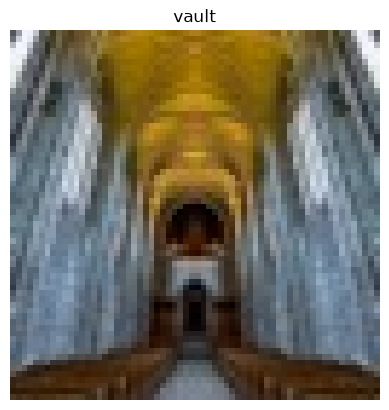

In [43]:
img = image.load_img(test_image)

plt.imshow(img)

plt.axis("off")

plt.title(prediction)

plt.show()

In [44]:
def retrieve_knowledge(predicted_class):

    query = predicted_class.replace("_", " ")

    retrieved_documents = retriever.invoke(query)

    return retrieved_documents

In [45]:
prediction = "bell_tower"

documents = retrieve_knowledge(prediction)

print(documents[0].metadata["source"])

print()

print(documents[0].page_content[:700])

bell_tower.txt

TITLE: Bell Tower

CATEGORY:
Vertical architectural structure.

DEFINITION:
A bell tower is a tall structure built to contain and support one or more
bells. It may be attached to a church, cathedral, monastery, civic building,
or other historic structure, or it may stand separately.

VISUAL IDENTIFICATION:
Bell towers usually rise well above the surrounding roof. Common shapes
include square, rectangular, circular, or polygonal towers. The upper section,
called the belfry, often contains large openings, arches, louvers, or open
tracery that allow the sound of the bells to travel outward.

FUNCTION:
Bells have been used to announce worship, mark time, celebrate events, warn
communities of dan


In [46]:
from langchain_ollama import OllamaLLM

llm = OllamaLLM(
    model="llama3"
)

print("Llama loaded.")

Llama loaded.


In [47]:
def explain_prediction(predicted_class):

    documents = retrieve_knowledge(predicted_class)

    context = documents[0].page_content

    prompt = f"""
You are a heritage architecture expert.

A computer vision model has identified the object as:

{predicted_class}

Using ONLY the information below, write a short explanation (about 120 words) that is easy for a student to understand.

Knowledge:

{context}

Do not invent facts.

Explanation:
"""

    response = llm.invoke(prompt)

    return response

In [48]:
prediction = "bell_tower"

explanation = explain_prediction(prediction)

print(explanation)

Here's a short explanation that's easy to understand:

A bell tower is a tall structure built to hold one or more bells. It's usually attached to a church, cathedral, or other historic building, but can also stand alone. Bell towers are designed to raise the sound of the bells above the surrounding area, allowing people to hear them from far away. They come in different shapes and sizes, such as square, circular, or rectangular, and may have features like arches, louvers, or open tracery to help the sound carry further.


In [49]:
def predict_and_explain(image_path):

    # Predict image
    predicted_class, confidence = predict_image(image_path)

    # Generate explanation
    explanation = explain_prediction(predicted_class)

    print("Prediction:", predicted_class)
    print("Confidence:", f"{confidence:.2%}")

    print("\nExplanation:\n")
    print(explanation)

    return predicted_class, confidence, explanation

In [53]:
predicted_class, confidence, explanation = predict_and_explain(
    "test/dome(outer)/741.jpg"
)

Prediction: dome(outer)
Confidence: 99.92%

Explanation:

Here's an explanation that's easy for students to understand:

The exterior dome refers to the visible, rounded roof structure seen on top of many historic buildings like churches, mosques, and palaces. It can be shaped like a hemisphere, onion, oval, or ribbed, and sometimes has decorations like lanterns or metalwork on top. The purpose of an exterior dome is to protect the interior space while also creating a strong architectural feature that stands out from a distance.


In [56]:
chat_history = []

current_prediction = {
    "predicted_class": predicted_class,
    "confidence": confidence,
    "explanation": explanation
}

print(current_prediction)

{'predicted_class': 'dome(outer)', 'confidence': 0.9992209672927856, 'explanation': "Here's an explanation that's easy for students to understand:\n\nThe exterior dome refers to the visible, rounded roof structure seen on top of many historic buildings like churches, mosques, and palaces. It can be shaped like a hemisphere, onion, oval, or ribbed, and sometimes has decorations like lanterns or metalwork on top. The purpose of an exterior dome is to protect the interior space while also creating a strong architectural feature that stands out from a distance."}


In [57]:
print("Current element:", current_prediction["predicted_class"])
print("Confidence:", f'{current_prediction["confidence"]:.2%}')

Current element: dome(outer)
Confidence: 99.92%


In [67]:
def ask_about_prediction(predicted_class, question, chat_history):

    documents = retrieve_knowledge(predicted_class)

    context = documents[0].page_content
    source = documents[0].metadata["source"]

    previous_conversation = "\n".join(chat_history)

    prompt = f"""
You are a heritage architecture assistant.

A computer vision model identified the architectural element as:

{predicted_class}

Use only the supplied knowledge to answer the question.
Use the conversation history to understand follow-up questions.
Do not invent facts.

If the answer is not available in the knowledge,
say that the information is not available in the knowledge base.

Conversation history:
{previous_conversation}

Knowledge:
{context}

Current question:
{question}

Give a clear and concise answer.

Answer:
"""

    answer = llm.invoke(prompt)

    chat_history.append(
        "User: " + question
    )

    chat_history.append(
        "Assistant: " + answer
    )

    return answer, source

In [68]:
chat_history = []

In [69]:
answer, source = ask_about_prediction(
    predicted_class,
    "What is its main purpose?",
    chat_history
)

print("Answer:\n")
print(answer)

print("\nSource:")
print(source)

Answer:

The main purpose of an exterior dome is to protect the interior while covering a large central space. Additionally, it efficiently distributes structural loads and creates a strong architectural landmark visible from long distances.

Source:
dome_outer.txt


In [70]:
answer, source = ask_about_prediction(
    predicted_class,
    "Where is it usually found?",
    chat_history
)

print("Answer:\n")
print(answer)

print("\nSource:")
print(source)

Answer:

According to the knowledge provided, an exterior dome is usually found on top of historic buildings, such as churches, cathedrals, mosques, palaces, and civic buildings.

Source:
dome_outer.txt


In [71]:
def reset_chat():
    return []

In [72]:
chat_history = reset_chat()

print(chat_history)

[]


In [73]:
prediction_data = {
    "predicted_class": predicted_class,
    "display_name": predicted_class.replace("_", " ").replace("(", " ").replace(")", "").title(),
    "confidence": confidence,
    "confidence_percent": round(confidence * 100, 2),
    "explanation": explanation
}

prediction_data

{'predicted_class': 'dome(outer)',
 'display_name': 'Dome Outer',
 'confidence': 0.9992209672927856,
 'confidence_percent': 99.92,
 'explanation': "Here's an explanation that's easy for students to understand:\n\nThe exterior dome refers to the visible, rounded roof structure seen on top of many historic buildings like churches, mosques, and palaces. It can be shaped like a hemisphere, onion, oval, or ribbed, and sometimes has decorations like lanterns or metalwork on top. The purpose of an exterior dome is to protect the interior space while also creating a strong architectural feature that stands out from a distance."}

In [74]:
!pip install streamlit

   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.4 MB 1.5 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/10.4 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/10.4 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/10.4 MB 1.1 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/10.4 MB 1.1 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/10.4 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 1.8/10.4 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/10.4 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/10.4 MB 1.1 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/10.4 MB 1.1 MB/s eta 0:00:08
   ---------- ----------------------------- 2.6/10.4 MB 1.1 MB/s eta 0:00:08
   ----------

In [75]:
import sys

print(sys.executable)

C:\Users\Yeshan\Desktop\Data Science\BSC\Machine Learning and Related Applications\CW\cv_env\Scripts\python.exe
